<center>
<h1><font face="Garamond" size="6" color="#1A5276"><b>📧 Naive Bayes for Text Classification</b></font></h1>
<h3><font face="Georgia">A Practical Guide to Spam Detection with scikit-learn</font></h3>
<p><font face="Georgia" color="red"><b>By: Siman Giri</b></font></p>
</center>
<hr>


<font face="Georgia" size="4">
In this tutorial, we'll explore a classic algorithm perfect for text classification - <b>Naive Bayes</b>:<br>We'll apply it to the classic problem of <b>spam detection</b> — classifying emails as "spam" or "ham" (legitimate).
</font>
<hr>

<font face="Georgia" size="4">
<b>🎯 Learning Objectives</b>

By the end of this tutorial, you will be able to:

1. <b>Understand</b> probability fundamentals (Joint, Conditional, Marginal, Bayes' Theorem)
2. <b>Explain</b> the "naive" assumption and why it works for text
3. <b>Implement</b> text preprocessing pipelines for classification
4. <b>Build</b> a spam detector using <code>MultinomialNB</code>
5. <b>Evaluate</b> classifier performance with appropriate metrics
6. <b>Compare</b> different Naive Bayes variants in scikit-learn
</font>

<hr>
<font face="Georgia" size="4">
<b>📚 Tutorial Structure</b><br><br>
This Tutorial consists of two Parts:<br>
<font color="#6A5ACD"><b>Part I - Theoretical Understanding of Naive Bayes</b></font><br>
<font color="#FF8C00"><b>Part II - Implementing Naive Bayes for Email Classification</b></font><br>


<!-- ========== PART 1: HANDS-ON IMPLEMENTATION ========== -->
<center>
<h1><font face="Georgia" size="7" color="#2C3E50">🧮 Part 1: Naive Bayes Theory</font></h1>
<font face="Georgia" size="4" color="#7F8C8D">Probability, Bayes' Theorem, and the "Naive" Assumption</font>
</center>
<hr>

<!-- ========== SECTION 1: PROBABILITY FOUNDATIONS ========== -->
# <font face="Georgia" size="5" color="#2E86C1"><b>📊 Section 1: Probability Foundations for Naive Bayes</b></font>

<!-- ========== SECTION 2: PROBABILITY FOUNDATIONS ========== -->
## <font face="Georgia" size="5" color="#2E86C1"><b>📊 Section 1.1: Some key concepts from probability:</b></font>

<font face="Times New Roman" font size="4">
To understand how Naive Bayes works, we need to review three key probability concepts. Let's illustrate them with our spam detection example.
<br>


<center>
<table border="1" cellpadding="10" cellspacing="0" style="border-collapse: collapse; font-face: Georgia;">
<tr>
<th>Probability Type</th>
<th>Notation</th>
<th>Meaning</th>
<th>Spam Detection Example</th>
</tr>
<tr>
<td><b>Joint Probability</b></td>
<td><b>P(A, B)</b></td>
<td>Probability of <i>both</i> events happening together</td>
<td><b>P("winner", Spam)</b> = Probability an email is <i>both</i> spam <i>and</i> contains "winner"</td>
</tr>
<tr>
<td><b>Conditional Probability</b></td>
<td><b>P(A|B)</b></td>
<td>Probability of A <i>given that</i> B occurred</td>
<td><b>P("winner"|Spam)</b> = Probability email contains "winner" <i>given that</i> it's spam</td>
</tr>
<tr>
<td><b>Marginal Probability</b></td>
<td><b>P(A)</b></td>
<td>Probability of a single event (ignoring others)</td>
<td><b>P(Spam)</b> = Overall probability any email is spam</td>
</tr>
</table>
</center>
</font>

### <font face="Georgia" font size="3">
<b>📊 Concrete Example with 1000 Emails:</b><br>

Suppose our dataset contains:
<pre>
Total emails: 1000
Spam emails: 250 (25%)
Ham emails: 750 (75%)
Spam with "winner": 80
Ham with "winner": 20
</pre>
</font>
<font face="Georgia" font size="3">
<b>Marginal Probability Calculations:</b>
<pre>
&nbsp;&nbsp;&nbsp;→ <code>P(Spam) = 250 / 1000 = 0.25</code>
&nbsp;&nbsp;&nbsp;→ <code>P(Ham) = 750 / 1000 = 0.75</code>
&nbsp;&nbsp;&nbsp;→ <code>P("winner") = 100 / 1000 = 0.10</code>
</pre>
<font size="3">
<b>Joint Probability Calculations:</b>
<pre>
&nbsp;&nbsp;&nbsp;→ <code>P(Spam, "winner") = 80 / 1000 = 0.08</code>
&nbsp;&nbsp;&nbsp;→ <code>P(Ham, "winner") = 20 / 1000 = 0.02</code>
</pre>
<font size="3">
<b>Conditional Probability Calculations:</b>
<pre>
&nbsp;&nbsp;&nbsp;→ <code>P("winner"|Spam) = 80 / 250 = 0.32</code> (32% of spam has "winner")
&nbsp;&nbsp;&nbsp;→ <code>P("winner"|Ham) = 20 / 750 ≈ 0.0267</code> (2.67% of ham has "winner")
&nbsp;&nbsp;&nbsp;→ <code>P(Spam|"winner") = 80 / 100 = 0.80</code> (80% of "winner" emails are spam!)
</pre>
</font>

<hr width="50%">

<font face="Georgia" font size="3">
<b>🔗 The Fundamental Relationship:</b><br>

All three probabilities are connected by this rule:
<center>
<b>
<code>P(A, B) = P(A|B) × P(B) = P(B|A) × P(A)</code>
</center>
</b>
<b> This is also known as Chain Rule of Probability.</b>

<b>Verification with our example:</b><br>
<pre>
<code>P(Spam, "winner") = P("winner"|Spam) × P(Spam)</code>
<code>0.08 = 0.32 × 0.25 ✓</code>
</pre>
Both equal 0.08, confirming the relationship holds!
</font>

<font face="Georgia" font size="3">
<b>📐 General Definition of Chain Rule:</b><br>
For multiple events A₁, A₂, ..., Aₙ, the chain rule extends to:
<center>
<b>
<code>P(A₁, A₂, ..., Aₙ) = P(A₁) × P(A₂|A₁) × P(A₃|A₁,A₂) × ... × P(Aₙ|A₁,A₂,...,Aₙ₋₁)</code>
</b>
</center>
Each term conditions on <i>all previous events</i>.<br>
This shows how joint probabilities can be broken down into a product of conditional probabilities.
</font>
<hr width=70%>
<br>
<font face="Georgia" font size="3">
<b>🎯 Special Case: Independent Events</b><br>
When events A₁, A₂, ..., Aₙ are <b>mutually independent</b> (occurrence of any event doesn't affect others), the chain rule simplifies dramatically:

<center>
<b>
<code>If A₁, A₂, ..., Aₙ are mutually independent:</code><br>
<code>P(A₁, A₂, ..., Aₙ) = P(A₁) × P(A₂) × ... × P(Aₙ)</code><br>
<code>and for any Aᵢ and Aⱼ: P(Aᵢ|Aⱼ) = P(Aᵢ)</code>
</center>
</b>
</font>

###

## <font face="Georgia" size="5" color="#2E86C1"><b>📊 Section 1.2: The Bayes Foundations</b></font>
<font face="Times New Roman" font size="3">
<b>Bayes' Theorem</b> gives us the mathematical tool to "flip" conditional probabilities, which is exactly what we need for classification. It transforms what we <i>can</i> count in training data into what we <i>want</i> to predict for new data.

<b>Bayes Theorem or Bayes Rule</b> can be written as:<br>


For our example:
<center>
<font size="+1">
$$
P(\text{Class}|\text{Evidence}) = \frac{P(\text{Evidence}|\text{Class}) \times P(\text{Class})}{P(\text{Evidence})}
$$
</font>
</center>

<font face="Georgia" size="3"><b> Breaking Down Each Term:</b>
<font face="Times New Roman">

<b>🔹 P(Class|Evidence) - The POSTERIOR</b>

*   <b>Meaning:</b> Probability of a class GIVEN the observed evidence/features
*   <b>What it represents:</b> Our <i>updated belief</i> after seeing the evidence
*   <b>In classification:</b> This is what we want to predict!
*   <b>Spam example:</b> <code>P(Spam|"winner", "free", "urgent")</code> - Probability an email is spam given it contains these words

<b>🔹 P(Evidence|Class) - The LIKELIHOOD</b>

*   <b>Meaning:</b> Probability of seeing this evidence GIVEN a particular class
*   <b>What it represents:</b> How "characteristic" these features are for each class
*   <b>In classification:</b> What we learn from training data by counting
*   <b>Spam example:</b> <code>P("winner", "free", "urgent"|Spam)</code> - How often spam emails contain these words
<b>🔹 P(Class) - The PRIOR</b>

*   <b>Meaning:</b> Initial probability of each class before seeing evidence
*   <b>What it represents:</b> Our <i>baseline belief</i> about class distribution
*   <b>In classification:</b> Simply the proportion of each class in training data
*   <b>Spam example:</b> <code>P(Spam) = 0.25</code> - 25% of all emails are spam
<b>🔹 P(Evidence) - The EVIDENCE (Marginal/Marginalizing Constant)</b>

*    <b>Meaning:</b> Overall probability of seeing this evidence across ALL classes
*   <b>What it represents:</b> A normalizing factor that makes probabilities sum to 1
*   <b>In classification:</b> Can be calculated as: <code>P(Evidence) = Σ[P(Evidence|Class) × P(Class)]</code><br>
*   <b>Spam example:</b> <code>P("winner", "free", "urgent")</code> - Overall chance any email contains these words















<hr width="70%">
<font face="Georgia" size="3">
<b>📝 Complete Spam Example Walkthrough:</b><br>
</font>
<font face="Times New Roman">
Let's say we have these statistics from our email dataset:
<pre>
1.   <b>PRIORS:
         P(Spam) = 0.25 &nbsp;&nbsp;&nbsp;→ (25% of emails are spam)
         P(Ham) = 0.75 &nbsp;&nbsp;&nbsp;→ (75% of emails are ham)
2.   LIKELIHOODS for word "winner":
        P("winner"|Spam) = 0.40 &nbsp;&nbsp;&nbsp;→ (40% of spam contains "winner")
        P("winner"|Ham) = 0.05 &nbsp;&nbsp;&nbsp;→ (5% of ham contains "winner")
3.   MARGINAL PROBABILITY of "winner":
        P("winner") = P("winner"|Spam) × P(Spam) + P("winner"|Ham) × P(Ham)
                    = (0.40 × 0.25) + (0.05 × 0.75)
                    = 0.10 + 0.0375 = 0.1375
</pre>
</b>
<b> Now apply Baye's Theorem:</b><br>
<center>
<code>P(Spam|"winner") = [P("winner"|Spam) × P(Spam)] / P("winner")</code><br>
<code>                = (0.40 × 0.25) / 0.1375</code><br>
<code>                = 0.10 / 0.1375 ≈ 0.727</code>
</center>
<br>
<center>
<b>RESULT: &nbsp; P(Spam|"winner") ≈ 72.7%</b>
</center>
<b>Interpretation:</b> If an email contains the word "winner", there's a <b>72.7% chance it's spam!</b><br>
<b>Compare with prior:</b> Before seeing "winner", we thought <code>P(Spam) = 25%</code>. After seeing <b>"winner",</b> our <b>belief updates to 72.7% </b><br>That's the power of evidence!
</font>

###<font face="Georgia" size="3"> <b>🧠 Why This is Perfect for Classification?</b></font>
<font face="Times New Roman" size="3">
<div style="padding-left: 50px;">
<b>1. Natural Probabilistic Output:</b> We get actual probabilities (0-1) not just class labels<br>
<b>2. Incorporates Prior Knowledge:</b> Uses overall class distribution via priors<br>
<b>3. Evidence Updates Beliefs:</b> Features adjust our confidence in predictions<br>
<b>4. Handles Missing Data:</b> If word never seen, its likelihood affects prediction appropriately<br>
<b>5. Multi-class Ready:</b> Easily extends to multiple classes
</div>
<font size="3">
<hr>
<b>🎯 For Multiple Words (like real emails):</b><br>

Bayes' Theorem extends naturally:
<center>
<code><b>P(Spam|w₁, w₂, ..., wₙ) ∝ P(w₁|Spam) × P(w₂|Spam) × ... × P(wₙ|Spam) × P(Spam)</code></b>
</center>
The "∝" means "proportional to" - we calculate for all classes and compare!
</font>
<br>
<font size="3">
<b>💡 Key Insight:</b> Bayes' Theorem converts our countable likelihoods (<code><b>P(word|class)</code></b>) into the predictions we need (<code><b>P(class|words)</code></b>).

This elegant "flip" is why it's so powerful for classification!
</font>
</font>

<!-- ========== SECTION 2: NAIVE BAYES THEORY ========== -->
<font face="Georgia" size="5" color="#2E86C1"><b>🧮 Section 2: Understanding Naive Bayes</b></font>

## <font face="Georgia" size="5" color="#191970"><b>Section 2.1 From Bayes' Theorem to Naive Bayes Classifier</b></font>

<font face="Times New Roman" size="3">
Baye's Theorem gives us the perfect foundation for classification, but we face a practical challenge:

1.   <b> How do we handle multiple features (words) in real emails?</b><br>
For an email with words <b>w₁, w₂, ..., wₙ,</b> Bayes' Theorem says:
<center>
<code><b>P(Spam|w₁, w₂, ..., wₙ) = [P(w₁, w₂, ..., wₙ|Spam) × P(Spam)] / P(w₁, w₂, ..., wₙ)</b></code>
</center>
The problem is calculating <b><code>P(w₁, w₂, ..., wₙ|Spam)</code></b> - the joint probability of seeing all these words together in spam.<br>
This requires enormous amounts of data and creates computational challenges.

2.   <b>📈 The Curse of Dimensionality:</b><br>
With a vocabulary of 10,000 words, there are 2¹⁰⁰⁰⁰ possible word combinations! We can never have enough data to estimate all these joint probabilities accurately.

<b>✨ The Solution: Make a "Naive" Assumption</b><br>
We simplify by assuming words are <b>conditionally independent</b> given the class:
<center>
<code><b>P(w₁, w₂, ..., wₙ|Spam) ≈ P(w₁|Spam) × P(w₂|Spam) × ... × P(wₙ|Spam)</code></b>
</center>
This turns an impossible estimation problem into a simple multiplication of individual word probabilities!




## <font face="Georgia" size="5" color="#191970"><b>Section 2.2 The Naive Assumptions and Why it Works anyway?</b></font>

<font face="Times New Roman" size="3"><br>
<b>🧠 Assumption 1: Conditional Independence</b><br>
The core assumption: Features (words) are independent <i>given the class</i>. i.e.<br>
We simplify by assuming words are <b>conditionally independent</b> given the class:
<center><b>
<code>P(w₁, w₂, ..., wₙ|Spam) ≈ P(w₁|Spam) × P(w₂|Spam) × ... × P(wₙ|Spam)</code>
</b>
</center>
This turns an impossible estimation problem into a simple multiplication of individual word probabilities!<br>
<font size="3"><i><b>Reality check:</b></i> Words aren't truly independent ("free" often appears with "money"), but the assumption works <b>surprisingly well!</b>
<br>
<hr>
 <b>📝 Assumption 2: Bag-of-Words Model</b><br>

*   Ignores word order and grammar<br>
*   Treats each word position as independent<br>
*   Only counts word occurrences/frequencies<br>
<font size="3"><b><i>Example:</b></i> "Click here now" and "Now click here" are treated identically</font>
<hr>
<b>⚖️ Assumption 3: Equal Feature Importance</b><br>
All words contribute equally to the classification decision (unless their probabilities differ significantly).
</font>
<hr>

<font face="Georgia" size="4" color="#191970">
<b>Why These "Naive" Assumptions Still Work:</b>
</font>

<div style="padding-left: 30px;">
<font face="Times New Roman" size="3">
<b>1. Classification vs. Probability Estimation:</b><br>
&nbsp;&nbsp;We only need the <i>relative order</i> of class scores, not perfect probabilities<br>
<b>2. Error Compensation:</b><br>
&nbsp;&nbsp;Errors from the independence assumption often cancel out in practice<br>
<b>3. Optimal Decision Boundaries:</b><br>
&nbsp;&nbsp;Naive Bayes finds good decision boundaries even with wrong assumptions<br>
<b>4. High-Dimensional Data:</b><br>
&nbsp;&nbsp;With many features, independence assumption becomes less harmful<br>
<b>5. Efficient Learning:</b><br>
&nbsp;&nbsp;Estimating individual P(w|c) is much easier than joint probabilities
</font>
</div>

<pre>
<center>
<table border="1" cellpadding="8" cellspacing="0" style="border-collapse: collapse; margin: 15px; font-family: Georgia; width: 80%;">
<tr style="background-color: #f8f9fa;">
<th>Assumption</th>
<th>What It Means</th>
<th>Why We Accept It</th>
</tr>
<tr>
<td><b>Conditional Independence</b></td>
<td>Words don't influence each other given class</td>
<td>Makes computation feasible; works well in practice</td>
</tr>
<tr>
<td><b>Bag-of-Words</b></td>
<td>Ignores word order and grammar</td>
<td>Simplifies feature representation; captures vocabulary</td>
</tr>
<tr>
<td><b>Equal Importance</b></td>
<td>All words treated equally initially</td>
<td>Probabilities naturally weight important words higher</td>
</tr>
</table>
</center>
</pre>
<font face="Times New Roman" size="3">
<b>💡 Key Insight:</b> Naive Bayes is called <b>"naive"</b> not because it's simple-minded, but because it makes <b>bold simplifying assumptions</b> that turn an <b>intractable problem into a practical solution</b>|. The beauty is that despite these assumptions, it often performs remarkably well!
</font>

## <font face="Georgia" size="5" color="#191970"><b>Section 2.3 The Naive Bayes Algorithm:</b></font>
<font face="Times New Roman" size="3">
<b>🧮 Naive Bayes Algorithm in a Nutshell:</b><br>
Naive Bayes is a <b>probabilistic classification algorithm</b> that applies Bayes' Theorem with a key simplifying assumption:<b><i>features are conditionally independent given the class</i></b>. Despite this <b>"naive" assumption</b>, it performs remarkably well for text classification and other high-dimensional problems.
</font>


## <font face="Georgia" size="5" color="#191970"><b>Section 2.4 The Naive Bayes Algorithm - From Text Classification Perspective:</b></font>
<font face="Times New Roman" size="3">

<font face="Times New Roman" size="3">
<b>📌 Scope of This Formulation:</b><br>
The following formulation is presented in the context of <b>text classification</b> (where documents are texts and features are words), as this is Naive Bayes' most common and successful application. However, the same mathematical framework extends naturally to <i>any classification problem</i> with discrete features.

<blockquote style="margin: 10px 30px; padding: 10px 15px; border-left: 3px solid #4A90E2; background-color: #f8f9fa;">
<b>Note on General Applicability:</b><br>
While we use text-specific terminology (documents, words), replace:<br>
• <code>d</code> (document) → any data instance<br>
• Words/features → any discrete attributes<br>
• Classes → any target categories<br>
The core probability theory remains identical.
</blockquote>
</font>

<font face="Georgia" size="4" color="#1A4B8C"><b>📋 Formal Problem Statement & Notation</b></font>

<font face="Times New Roman" size="3">
<b>Notation Definitions:</b><br>
• <code>d</code> = A document (e.g., email, text message, article)<br>
• <code>c</code> = A class/category (e.g., "spam" or "ham" for email classification)<br>
• <code>C</code> = The set of all possible classes <code>{c₁, c₂, ..., cₘ}</code><br>
• <code>ĉ</code> = Predicted class for document <code>d</code>
</font>

<br>

<font face="Times New Roman" size="3">
<b>Naive Bayes as a Probabilistic Classifier:</b><br>
For a document <code>d</code>, out of all classes <code>c ∈ C</code>, Naive Bayes returns:
$$
\mathbf{
\hat{c} = \arg\max_{c \in C} P(c \mid d)}
$$
where <code>ĉ</code> is the class with maximum <b>posterior probability</b>.
</font>
<br>
<br>
<font face="Times New Roman" size="3">
<b>🔍 What is P(c|d)? - The Posterior Probability</b><br>
<code>P(c|d)</code> represents our <i>updated belief</i> about the class after observing the document. It answers: <i>"Given this specific document d, what's the probability it belongs to class c?"</i>
</font>
<br><br>
<font face="Times New Roman" size="3">
<b>Applying Bayes' Rule:</b>
$$
\mathbf{P(c \mid d) = \frac{P(d \mid c)\times P(c)}{P(d)}}
$$
</font>

<font face="Times New Roman" size="3">
<b>Term-by-Term Breakdown:</b><br>
• $\mathbf{P(c|d)}$ = <b>Posterior</b>: Probability of class given document (what we want)<br>
• $\mathbf{P(d|c)}$ = <b>Likelihood</b>: Probability of document given class (learned from data)<br>
• $\mathbf{P(c)}$ = <b>Prior</b>: Overall probability of class (class distribution)<br>
• $\mathbf{P(d)}$ = <b>Evidence</b>: Overall probability of document (normalizing constant)
</font>
<br><br>
<font face="Times New Roman" size="3">
<b>Most Likely Class:</b>
$$
\boldsymbol{\hat{c} = \arg\max_{c \in C} \frac{P(d \mid c)\times P(c)}{P(d)}}
$$
<b> For the Context of Text classification, the above statement could be written as:</b>
$$
\boldsymbol{\hat{c} = \arg\max_{c \in C} \frac{P(w_1,w_2, \dots ,w_n) \mid c)\times P(c)}{P(w_1, w_2, \dots , w_n)}}
$$
Since all documents are composed of words $\Rightarrow \boldsymbol{d = \{w_1, w_2, \dots, w_n\}}$

</font>
<br>
<font face="Times New Roman" size="3">
<b>Simplified Form (In Practice):</b><br>
Since <code><b>P(d)</b></code> is constant for all classes:
$$
\boldsymbol{\hat{c} = \arg\max_{c \in C} P(d \mid c)\times P(c)}
$$

The scaling factor doesn't change which class has maximum value.<br>
<b> For the Text Classification:</b>
$$
\boldsymbol{\hat{c} = \arg\max_{c \in C} P(w_1, w_2, \dots ,w_n \mid c)\times P(c)}
$$
</font>
<font face="Georgia" size="3" color="#1A4B8C">This is where<b>"Naive" Assumptions kicks in:</b>
</font>
<font face="Times New Roman" size="3">
Computing
$$\boldsymbol{P(w_1, w_2, \dots, w_n \mid c)}$$
directly is challenging. Therefore, under the assumptions of:
1.   <b>Bag-of-Words model:</b> The position of a word does not matter
2.   <b>Conditional independence:</b> All words are independent given the class
$$
\boldsymbol{
P(w_1, w_2, \dots, w_n \mid c)
=
P(w_1 \mid c)\times P(w_2 \mid c)\times \dots \times P(w_n \mid c)
=
\prod_{i=1}^{n} P(w_i \mid c)
}
$$

</font>
<font face="Times New Roman" size="3"><b> So the Naive Bayes Classification Rule could be stated as:</b>
$$
\boldsymbol{
\hat{c} = \arg\max_{c \in C} \left[ \prod_{i=1}^{n} P(w_i \mid c) \right] \times P(c)
}\\
\textbf{(This is a Multinomual Naive Bayes Classifier)}
$$
<br><br>
<b>Cautions:</b><br>

To apply the Naive Bayes classifier to text, we need to consider word positions.  
The classifier can be written as:

$$
C_{NB} = \arg\max_{c_j \in C} P(c_j) × \prod_{i \in \text{positions}} P(w_i \mid c_j)
$$

Multiplying lots of probabilities can result in <b>floating-point underflow</b>,  
for example: 0.0006 × 0.0009 × 0.01 …  

<b>Idea: Use logarithms!</b><br>
Taking the log of the above expression transforms the product into a sum:

$$
C_{NB} = \arg\max_{c_j \in C} \log \Big[ P(c_j) \prod_{i \in \text{positions}} P(w_i \mid c_j) \Big]
$$

Using the log property <code>log(ab) = log a + log b</code>, we can rewrite it as:

$$
C_{NB} = \arg\max_{c_j \in C} \Big[ \log P(c_j) + \sum_{i \in \text{positions}} \log P(w_i \mid c_j) \Big]
$$
<hr>
<font face="Times New Roman" size="3">
<b>🎯 Practical Interpretation:</b><br>
We predict the class that maximizes the product of:

1.   How typical this document is for the class $\mathbf{P(w_1, w_2, \dots, w_n)}$?
2.   How common the class is overall $\mathbf{P(c))?}$
</font>

<font face="Times New Roman" size="4">
<b>📧 Concrete Example with Step-by-Step Calculation:</b><br>
Email Content: <code>"Win free prize! Claim now."</code><br><br>

<b>Step 1: Extract Features</b><br>
Words: {"win", "free", "prize", "claim"} (after cleaning: lowercase, remove punctuation)<br><br>

<b>Step 2: Known Statistics from Training Data</b><br>
• Prior Probabilities:<br>
&nbsp;&nbsp;<code>P(spam) = 0.30</code> (30% of training emails were spam)<br>
&nbsp;&nbsp;<code>P(ham) = 0.70</code> (70% were legitimate)<br><br>

• Likelihoods (estimated from training):<br>
&nbsp;&nbsp;<code>P("win","free","prize","claim"|spam) = 0.25</code><br>
&nbsp;&nbsp;&nbsp;&nbsp;(25% of spam emails contain ALL these words)<br>
&nbsp;&nbsp;<code>P("win","free","prize","claim"|ham) = 0.01</code><br>
&nbsp;&nbsp;&nbsp;&nbsp;(Only 1% of legitimate emails contain ALL these words)<br><br>

<b>Step 3: Calculate Scores for Each Class</b><br>
<center>
<code>Score(spam) = P(spam) × P("win","free","prize","claim"|spam)</code><br>
<code>Score(spam) = 0.30 × 0.25 = 0.075</code><br><br>

<code>Score(ham) = P(ham) × P("win","free","prize","claim"|ham)</code><br>
<code>Score(ham) = 0.70 × 0.01 = 0.007</code>
</center><br>

<b>Step 4: Make Prediction</b><br>
<center>
<code>ĉ = argmax(Score(spam), Score(ham)) = argmax(0.075, 0.007) = spam</code>
</center><br>

<b>Step 5: Interpretation</b><br>
• <b>Spam score (0.075)</b> is ~10.7× higher than ham score (0.007)<br>
• Even though legitimate emails are more common (P(ham)=0.70), the words are much more characteristic of spam<br>
• Strong evidence overrides the prior: email classified as <b>SPAM</b><br><br>

<b>📊 Probability Normalization (Optional):</b><br>
If we want actual probabilities instead of just classification:
<center>
<code>P(spam|email) = 0.075 / (0.075 + 0.007) ≈ 0.915 (91.5% spam)</code><br>
<code>P(ham|email) = 0.007 / (0.075 + 0.007) ≈ 0.085 (8.5% ham)</code>
</center>
We're 91.5% confident this is spam!
</font>

<!-- ========== PART 2: HANDS-ON IMPLEMENTATION ========== -->
<center>
<h1><font face="Georgia" size="6" color="#1A4B8C">🔧 Part 2: Implementing Naive Bayes for Email Classification</font></h2>
<font face="Georgia" size="4">From Theory to Practice with scikit-learn</font>
</center>

<hr>

<!-- SECTION 1: TEXT PREPROCESSING -->
#<font face="Georgia" size="4" color="#1A4B8C"><b>📝 Section 1: Text Data Preprocessing Fundamentals</b></font>

<font face="Times New Roman" size="3">
Before we can apply Naive Bayes to text data, we need to convert raw text into numerical features that the algorithm can understand. This process is called <b>text vectorization</b>.
</font>

##<font face="Times New Roman" size="3">
<b>🧹 Step 1: Text Cleaning Pipeline</b><br>
Raw text contains noise that we need to clean:

*   **Convert to lowercase**
*   **Remove punctuation and special characters**
*   **Remove numbers (optional)**
*   **Remove stopwords (common words like "the", "and", "is")**
*   **Stemming/Lemmatization (reduce words to root forms)**
</font>

In [ ]:
# Cell 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Download required NLTK data
nltk.download('stopwords')
nltk.download('wordnet')

print("✅ Libraries imported successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


✅ Libraries imported successfully!


In [ ]:
def clean_text(text, remove_stopwords=True, use_stemming=False):
    """
    Clean and preprocess text data

    Parameters:
    text (str): Input text to clean
    remove_stopwords (bool): Whether to remove stopwords
    use_stemming (bool): Use stemming if True, lemmatization if False

    Returns:
    str: Cleaned text
    """
    # Convert to lowercase
    text = text.lower()

    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize (split into words)
    words = text.split()

    # Remove stopwords if specified
    if remove_stopwords:
        stop_words = set(stopwords.words('english'))
        words = [w for w in words if w not in stop_words]

    # Apply stemming or lemmatization
    if use_stemming:
        stemmer = PorterStemmer()
        words = [stemmer.stem(w) for w in words]
    else:
        lemmatizer = WordNetLemmatizer()
        words = [lemmatizer.lemmatize(w) for w in words]

    # Join back to string
    return ' '.join(words)

# Example
sample_text = "Hello! This is a SAMPLE email with numbers 123 and special #tags."
print("Original:", sample_text)
print("Cleaned:", clean_text(sample_text))

Original: Hello! This is a SAMPLE email with numbers 123 and special #tags.
Cleaned: hello sample email number special tag


## <font face="Times New Roman" size="3"> <b>🔢 Step 2: Text Vectorization - Converting Words to Numbers</b>
Two main approaches in scikit-learn:
1. <b>CountVectorizer - Bag of Words (BoW)</b>

*   Creates a vocabulary from all words in corpus
*   Each document → vector of word counts
*   Simple but ignores word importance
2. <b>Tf - idf Vectorizer - Term Frequency-Inverse Document Frequency</b>

*   Weights words by their importance
*   TF: How often word appears in document
*   IDF: How rare word is across all documents
*   Downweights common words (like "the", "and")
</font>

In [ ]:
#CountVectorizer Example
from sklearn.feature_extraction.text import CountVectorizer

# Sample documents
documents = [
    "I love machine learning",
    "Machine learning is amazing",
    "I hate spam emails",
    "Spam emails are annoying"
]

# Create CountVectorizer
count_vectorizer = CountVectorizer()

# Fit and transform
X_counts = count_vectorizer.fit_transform(documents)

print("Vocabulary:", count_vectorizer.get_feature_names_out())
print("\nDocument-Term Matrix shape:", X_counts.shape)
print("\nMatrix (dense representation):")
print(X_counts.toarray())

Vocabulary: ['amazing' 'annoying' 'are' 'emails' 'hate' 'is' 'learning' 'love'
 'machine' 'spam']

Document-Term Matrix shape: (4, 10)

Matrix (dense representation):
[[0 0 0 0 0 0 1 1 1 0]
 [1 0 0 0 0 1 1 0 1 0]
 [0 0 0 1 1 0 0 0 0 1]
 [0 1 1 1 0 0 0 0 0 1]]


In [ ]:
# TF-IDF Vectorizer Example
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit and transform
X_tfidf = tfidf_vectorizer.fit_transform(documents)

print("Vocabulary:", tfidf_vectorizer.get_feature_names_out())
print("\nTF-IDF Matrix shape:", X_tfidf.shape)
print("\nTF-IDF Matrix:")
print(X_tfidf.toarray())

# Show the IDF values (inverse document frequency)
print("\nIDF values (lower = more common):")
for word, idf in zip(tfidf_vectorizer.get_feature_names_out(), tfidf_vectorizer.idf_):
    print(f"{word}: {idf:.3f}")

Vocabulary: ['amazing' 'annoying' 'are' 'emails' 'hate' 'is' 'learning' 'love'
 'machine' 'spam']

TF-IDF Matrix shape: (4, 10)

TF-IDF Matrix:
[[0.         0.         0.         0.         0.         0.
  0.52640543 0.66767854 0.52640543 0.        ]
 [0.55528266 0.         0.         0.         0.         0.55528266
  0.43779123 0.         0.43779123 0.        ]
 [0.         0.         0.         0.52640543 0.66767854 0.
  0.         0.         0.         0.52640543]
 [0.         0.55528266 0.55528266 0.43779123 0.         0.
  0.         0.         0.         0.43779123]]

IDF values (lower = more common):
amazing: 1.916
annoying: 1.916
are: 1.916
emails: 1.511
hate: 1.916
is: 1.916
learning: 1.511
love: 1.916
machine: 1.511
spam: 1.511


<font face="Times New Roman" size="3">
<b>📊 Comparison: CountVectorizer vs TF-IDF</b><br>

<center>
<table border="1" cellpadding="8" cellspacing="0" style="border-collapse: collapse;">
<tr style="background-color: #f8f9fa;">
<th>Aspect</th>
<th>CountVectorizer</th>
<th>TF-IDF Vectorizer</th>
</tr>
<tr>
<td><b>Approach</b></td>
<td>Raw word counts</td>
<td>Weighted word importance</td>
</tr>
<tr>
<td><b>Pros</b></td>
<td>Simple, fast, preserves frequency info</td>
<td>Downweights common words, captures importance</td>
</tr>
<tr>
<td><b>Cons</b></td>
<td>Common words dominate, no weighting</td>
<td>More computation, may lose some frequency info</td>
</tr>
<tr>
<td><b>When to Use</b></td>
<td>When word presence matters more than importance</td>
<td>When distinguishing important vs common words matters</td>
</tr>
</table>
</center>

<b>For spam detection:</b> TF-IDF often works better because it reduces the influence of common email words like "hello", "thanks", etc.
</font>


# <font face="Georgia" size="4" color="#1A4B8C"><b>🤖 Section 2: Building Naive Bayes Classifier</b></font>

<font face="Georgia" size="4" color="#1A4B8C">
<b>About - Scikit-learn's MultinomialNB</b><br></font>
<font face="Times New Roman" size="3"
Scikit-learn provides <code>MultinomialNB</code> which implements Naive Bayes for multinomially distributed data (perfect for word counts!). <br>
<b>📝 Basic Syntax:</b>
<br>
<code>from sklearn.naive_bayes import MultinomialNB</code><br>
<code>model = MultinomialNB(alpha=1.0, fit_prior=True, class_prior=None)</code>
<br>
<b>Key parameters:</b>

*   <code>alpha</code>: Laplace smoothing parameter (prevents zero probabilities)
*   <code>fit_prior</code>: Whether to learn class prior probabilities
*   <code>class_prior</code>: Prior probabilities of classes
</font>

<font face="Georgia" size="4" color="#1A4B8C"><b>📊 About the Dataset</b></font>

<font face="Times New Roman" size="3">
<b>Dataset: SMS Spam Collection Dataset</b><br>
This is a classic benchmark dataset for spam detection research, containing 5,574 SMS messages labeled as either <b>spam</b> or <b>ham</b> (legitimate).

<b>📈 Dataset Statistics:</b>
• <b>Total messages:</b> 5,574
• <b>Ham messages:</b> 4,827 (86.6%)
• <b>Spam messages:</b> 747 (13.4%)
• <b>Average length:</b> 80.5 characters per message
• <b>Language:</b> English

<b>📝 Data Format:</b>
Each row contains two tab-separated columns:
1. <b>Label:</b> Either "ham" or "spam"
2. <b>Message:</b> The raw SMS text

<b>🔍 Sample Messages:</b>
<blockquote style="border-left: 3px solid #4A90E2; padding-left: 15px; margin: 10px 0; font-style: italic;">
<b>Ham:</b> "Sorry, I'll call later"<br>
<b>Spam:</b> "Congratulations! You've won a $1,000 prize! Call now to claim."
</blockquote>
<b>⚠️ Important Note on Class Imbalance:</b>
The dataset has a natural imbalance (87% ham, 13% spam), which reflects real-world distribution. This means:
• Accuracy alone can be misleading (predicting "ham" always gives 87% accuracy!)
• We need metrics like precision, recall, and F1-score
• The model must be evaluated carefully
</font>

### <font face="Georgia" size="4"> <b>Step 1 - Load the dataset.</b>

In [ ]:
# Load the data
df = pd.read_csv("SMSSpamCollection", sep='\t', header=None, names=['label', 'message'])
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 messages:")
print(df.head())
print(f"\nClass distribution:")
print(df['label'].value_counts())

Dataset shape: (5572, 2)

First 5 messages:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


### <font face="Georgia" size="4"> <b>Step 2 - Clean the dataset.</b>

In [ ]:
# Clean the text messages
df['cleaned_message'] = df['message'].apply(lambda x: clean_text(x, remove_stopwords=True, use_stemming=False))

# Convert labels to binary (spam = 1, ham = 0)
df['label_binary'] = df['label'].map({'spam': 1, 'ham': 0})

print("Original message example:")
print(df.loc[0, 'message'])
print("\nCleaned message example:")
print(df.loc[0, 'cleaned_message'])
print(f"\nBinary labels: {df['label_binary'].unique()}")

Original message example:
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

Cleaned message example:
go jurong point crazy available bugis n great world la e buffet cine got amore wat

Binary labels: [0 1]


### <font face="Georgia" size="4"> <b>Step 3 - Split into Training and Test set.</b>

In [ ]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_message'],
    df['label_binary'],
    test_size=0.2,
    random_state=42,
    stratify=df['label_binary']
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
print(f"\nTraining class distribution:\n{y_train.value_counts(normalize=True)}")

Training set: 4457 samples
Testing set: 1115 samples

Training class distribution:
label_binary
0    0.865829
1    0.134171
Name: proportion, dtype: float64


### <font face="Georgia" size="4"> <b>Step 4 - Vectorize using TF-IDF (you can also try CountVectorizer!).</b>

In [ ]:
# Vectorize using TF-IDF (you can also try CountVectorizer!)
vectorizer = TfidfVectorizer(max_features=3000)  # Limit to top 3000 features
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"\nVectorized training shape: {X_train_vec.shape}")
print(f"Vocabulary size: {len(vectorizer.get_feature_names_out())}")


Vectorized training shape: (4457, 3000)
Vocabulary size: 3000


### <font face="Georgia" size="4"> <b>Step 5 - Train Naive Bayes Classifier.</b>

In [ ]:
# Initialize and train the model
nb_classifier = MultinomialNB(alpha=1.0)  # alpha=1 for Laplace smoothing
nb_classifier.fit(X_train_vec, y_train)
print("Model trained successfully!")

Model trained successfully!


In [ ]:
print(f"Class labels: {nb_classifier.classes_}")
# Priors
print(f"Class log priors: {nb_classifier.class_log_prior_}")
# Log-likelihoods
print("\nLog-likelihoods (feature probabilities given class):")
print(nb_classifier.feature_log_prob_)

# Optional: convert to normal probabilities
print("\nFeature probabilities (not log):")
print(np.exp(nb_classifier.feature_log_prob_))

Class labels: [0 1]
Class log priors: [-0.14406781 -2.00864042]

Log-likelihoods (feature probabilities given class):
[[-8.52696239 -8.4701068  -8.39362698 ... -8.81163149 -6.51617899
  -9.38984438]
 [-8.50958677 -8.50958677 -8.50958677 ... -8.50958677 -8.50958677
  -7.63656129]]

Feature probabilities (not log):
[[1.98055673e-04 2.09642511e-04 2.26304984e-04 ... 1.48989982e-04
  1.47931078e-03 8.35684599e-05]
 [2.01527084e-04 2.01527084e-04 2.01527084e-04 ... 2.01527084e-04
  2.01527084e-04 4.82484725e-04]]


<font face="Times New Roman" size="3">
<b>Class log priors learned:</b> <code><b>[-0.14406781  -2.00864042]</code></b><br>
<code><b>nb_classifier.class_log_prior_</b></code><br>
These values are the <b>natural logarithms</b> of the prior probabilities for each class.  
<code>MultinomialNB</code> uses log probabilities internally to avoid <b>floating-point underflow</b> when multiplying many small probability values.<br>
Taking the exponential of these values gives the actual class priors:

- <code>exp(-0.14406781)</code> ≈ <b>0.8658</b> &nbsp;→&nbsp; \(P(\text{ham})\)
- <code>exp(-2.00864042)</code> ≈ <b>0.1341</b> &nbsp;→&nbsp; \(P(\text{spam})\)

These results reflect the class distribution in the training data (approximately <b>86.6%</b> ham and <b>13.4%</b> spam), indicating that the model has correctly learned the initial class probabilities.
</font>
<br>
<hr>
<font face="Times New Roman" size="3">
<b> Class log-likelihoods learned:</b><br>
<code><b>nb_classifier.feature_log_prob_</b></code><br>
These values are the <b>natural logarithms</b> of the conditional probabilities
for each feature given each class, i.e., <code>log P(word_i | class_j)</code>.  
<code>MultinomialNB</code> uses log probabilities internally to avoid <b>floating-point underflow</b>
when multiplying many small probabilities across features.<br>
For example, if your vocabulary has 5 words and 2 classes, the first few log-likelihoods may look like:
<pre><b>
Class 0 (ham): [-3.9120, -2.3026, -4.0943, -3.2189, -2.9957]
Class 1 (spam): [-2.9957, -4.0943, -3.2189, -3.9120, -2.3026]
</b></pre>
Taking the exponential converts them back to normal probabilities:
<ul>
<li>exp(-3.9120) ≈ <b>0.020</b> → probability of word 1 given ham</li>
<li>exp(-2.9957) ≈ <b>0.050</b> → probability of word 1 given spam</li>
</ul>
These probabilities reflect how strongly each word is associated with each class.  
Words with higher probabilities for a class are more indicative of that class.
</font>
<hr>

### <font face="Georgia" size="4"> <b>Step 6 - Make predictions.</b>

In [ ]:
y_pred = nb_classifier.predict(X_test_vec)
y_pred_proba = nb_classifier.predict_proba(X_test_vec)

print(f"\nSample predictions (first 5):")
for i in range(5):
    print(f"Message: {X_test.iloc[i][:50]}...")
    print(f"  True: {'spam' if y_test.iloc[i]==1 else 'ham'}, Predicted: {'spam' if y_pred[i]==1 else 'ham'}")
    print(f"  Probabilities: [ham: {y_pred_proba[i][0]:.3f}, spam: {y_pred_proba[i][1]:.3f}]")


Sample predictions (first 5):
Message: need buy lunch eat maggi mee...
  True: ham, Predicted: ham
  Probabilities: [ham: 0.993, spam: 0.007]
Message: ok im sure time finish tomorrow wanna spend evenin...
  True: ham, Predicted: ham
  Probabilities: [ham: 0.999, spam: 0.001]
Message: waiting e car mum lor u leh reach home already...
  True: ham, Predicted: ham
  Probabilities: [ham: 0.997, spam: 0.003]
Message: cash prize claim call...
  True: spam, Predicted: spam
  Probabilities: [ham: 0.024, spam: 0.976]
Message: r home come within min...
  True: ham, Predicted: ham
  Probabilities: [ham: 0.948, spam: 0.052]


### <font face="Georgia" size="4"> <b>Step 7 - Evaluate the Model.</b>

Model Evaluation

Accuracy: 0.9713

Classification Report:
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       0.99      0.79      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115



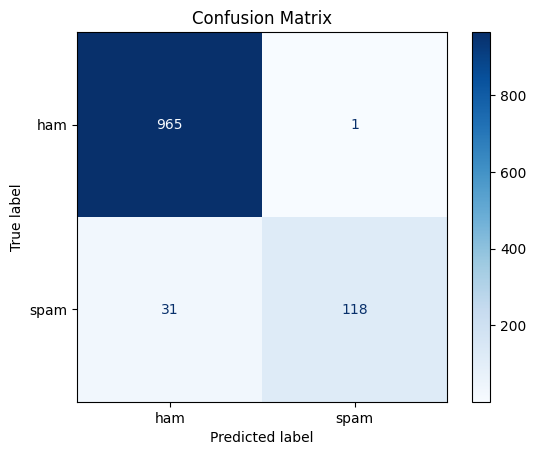


 Top 10 spam indicators:
  call: 0.0094
  free: 0.0066
  txt: 0.0048
  claim: 0.0046
  mobile: 0.0043
  text: 0.0041
  stop: 0.0041
  ur: 0.0039
  prize: 0.0038
  reply: 0.0036


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Model Evaluation\n")
print("="*50)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("="*50)
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))
print("="*50)
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ham', 'spam'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()
print("="*50)
# Most important features (words) for spam detection
feature_names = vectorizer.get_feature_names_out()
log_prob = nb_classifier.feature_log_prob_  # Log probabilities of features given class
# Get top 10 spam indicators
spam_log_prob = log_prob[1]  # Index 1 = spam class
top_spam_indices = spam_log_prob.argsort()[-10:][::-1]
print("\n Top 10 spam indicators:")
for idx in top_spam_indices:
    print(f"  {feature_names[idx]}: {np.exp(spam_log_prob[idx]):.4f}")

<font face="Times New Roman" size="3">
<b>🎯 Key Takeaways from Implementation:</b>

1. <b>Text preprocessing is crucial</b>: Cleaning and normalization significantly impact performance
2. <b>Vectorization choice matters</b>: TF-IDF often outperforms simple counts for text classification
3. <b>MultinomialNB is simple but effective</b>: With proper preprocessing, it achieves excellent results
4. <b>Feature analysis is insightful</b>: We can identify which words are strong spam indicators
5. <b>Smoothing (alpha) prevents issues</b>: Handles words not seen in training data


# <font face="Georgia" size="5" color="#228B22"> <b>💡 Next Steps to Try:</b></font>
<font face="Georgia" size="4">

*   <b>Experiment with different alpha values
*   Compare CountVectorizer vs TF-IDF performance
*   Add different Text Representation techniques like bigrams/trigrams as features
*   Try different text cleaning strategies</b>
</font>